# Pathway Moran's I + Per–Cell-Type Scoring

Standalone analysis: pick any pathway from the loaded GMT collections (hallmark, reactome, GO BP, curated), score it across all cells, compute Moran's I per tissue for treatments of interest, render a pathway × treatment heatmap, and produce a customizable cell-type × condition box plot of mean scores.

**Edit points (one per section):**
1. `pathway_panel` — which gene sets to score.
2. `analysis_treatments` — which treatments (and therefore tissues) to include.
3. `heatmap_treatments` / `heatmap_score_cols` — what to show in the heatmap.
4. `boxplot_cell_types` / `boxplot_score_col` / `boxplot_treatments` — what to show in the cell-type box plot.


# Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

import scanpy as sc
import squidpy as sq

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as spd


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


# Project paths and data load

In [2]:
zarr_file = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotations_400"

reference_dir = Path("/coh_labs/yunroseli/Jona/CAR-T/data/references")
pathway_dir = reference_dir / "pathways"

outdir = Path("/coh_labs/yunroseli/Jona/CAR-T/results/pathway_moransI_standalone")
outdir.mkdir(parents=True, exist_ok=True)

print(f"Pathway dir exists: {pathway_dir.exists()}")
print(f"Output dir: {outdir}")

sdata = spd.read_zarr(zarr_file)
adata = sdata.tables["segmentation_counts"]
print(adata)


Pathway dir exists: True
Output dir: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_moransI_standalone
AnnData object with n_obs × n_vars = 2088557 × 19059
    obs: 'sample', 'cell_id', 'region', 'TMA', 'mouse', 'tissue', 'condition', 'tumor_loc', 'replicate_num', 'c2l_argmax', 'c2l_permissive', 'c2l_strict', 'c2l_runnerup', 'c2l_consolidated', 'treatment'
    uns: 'spatialdata_attrs', 'normalization', 'log1p'
    obsm: 'c2l_q95', 'c2l_q05', 'spatial', 'c2l_means'
    layers: 'counts'


# Normalize counts for pathway scoring

# Load all pathway collections

Mirrors `Pathway_Visualization.ipynb`: every gene set across all four GMT files is loaded into a single `all_gene_sets` dict, with `gene_set_metadata` describing each one's collection and size.

In [3]:
gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  pathway_dir / "m2.cp.v2026.1.Mm.symbols.gmt",
}

for name, path in gmt_files.items():
    print(name, path, path.exists())


hallmark /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/mh.all.v2026.1.Mm.symbols.gmt True
reactome /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.reactome.v2026.1.Mm.symbols.gmt True
go_bp /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m5.go.bp.v2026.1.Mm.symbols.gmt True
curated /coh_labs/yunroseli/Jona/CAR-T/data/references/pathways/m2.cp.v2026.1.Mm.symbols.gmt True


In [4]:
def read_gmt(gmt_path):
    gene_sets = {}
    rows = []
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            gene_set, description = parts[0], parts[1]
            genes = parts[2:]
            gene_sets[gene_set] = genes
            rows.append({
                "gene_set": gene_set,
                "description": description,
                "n_genes": len(genes),
                "source_file": Path(gmt_path).name,
            })
    return gene_sets, pd.DataFrame(rows)


def find_pathway_names(pathways, search_term):
    if isinstance(search_term, str):
        search_term = [search_term]
    return [k for k in pathways.keys() if any(t.lower() in k.lower() for t in search_term)]


all_gene_sets = {}
gene_set_metadata_list = []
for collection, path in gmt_files.items():
    gs, meta = read_gmt(path)
    meta["collection"] = collection
    all_gene_sets.update(gs)
    gene_set_metadata_list.append(meta)

gene_set_metadata = pd.concat(gene_set_metadata_list, ignore_index=True)
print(f"Total gene sets loaded: {len(all_gene_sets):,}")
display(gene_set_metadata.groupby("collection")[["gene_set"]].count())


Total gene sets loaded: 9,618


,gene_set
collection,
curated,1787
go_bp,7781
hallmark,50
reactome,1333


## Searching for pathway names

Use `find_pathway_names(all_gene_sets, ["ifn", "interferon"])` to discover the exact MSigDB names to put into `pathway_panel` below.

In [5]:
# Example searches — edit/run as needed.
print(find_pathway_names(all_gene_sets, ["interferon_gamma"])[:10])
print(find_pathway_names(all_gene_sets, ["cytotoxicity"])[:10])
print(find_pathway_names(all_gene_sets, ["mhc"])[:10])


['HALLMARK_INTERFERON_GAMMA_RESPONSE', 'REACTOME_INTERFERON_GAMMA_SIGNALING']
['GOBP_ANTIBODY_DEPENDENT_CELLULAR_CYTOTOXICITY', 'GOBP_COMPLEMENT_DEPENDENT_CYTOTOXICITY', 'GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY', 'GOBP_MICROGLIAL_CELL_MEDIATED_CYTOTOXICITY', 'GOBP_NEGATIVE_REGULATION_OF_COMPLEMENT_DEPENDENT_CYTOTOXICITY', 'GOBP_NEGATIVE_REGULATION_OF_T_CELL_MEDIATED_CYTOTOXICITY', 'GOBP_NEUTROPHIL_MEDIATED_CYTOTOXICITY', 'GOBP_POSITIVE_REGULATION_OF_NEUTROPHIL_MEDIATED_CYTOTOXICITY', 'GOBP_PROTECTION_FROM_NATURAL_KILLER_CELL_MEDIATED_CYTOTOXICITY', 'GOBP_REGULATION_OF_COMPLEMENT_DEPENDENT_CYTOTOXICITY']
['REACTOME_ANTIGEN_PRESENTATION_FOLDING_ASSEMBLY_AND_PEPTIDE_LOADING_OF_CLASS_I_MHC', 'REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION', 'REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION', 'GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I', 'GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II', 'GOBP_ANTIGEN_PR

# Define the pathway panel and score

Left = short name (becomes the score column `<short_name>_score`).
Right = exact MSigDB gene set name.

In [6]:
pathway_panel = {
    # IFN/inflammatory activation
    "IFN_gamma": "HALLMARK_INTERFERON_GAMMA_RESPONSE",

    # Broad antigen processing/presentation
    "AntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION"
    ),

    # Peptide antigen presentation
    "PeptideAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN"
    ),

    # Exogenous antigen presentation
    "ExogenousAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_ANTIGEN"
    ),

    # Exogenous peptide antigen presentation
    "ExogenousPeptideAntigenPresentation_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN"
    ),

    # MHC-II/exogenous peptide antigen presentation
    "MHCII_ExogenousPeptide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),

    # MHC-II peptide/polysaccharide antigen presentation
    "MHCII_PeptidePolysaccharide_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_OR_POLYSACCHARIDE_ANTIGEN_VIA_MHC_CLASS_II"
    ),

    # MHC-I antigen presentation
    "MHCI_PeptideAntigen_GO": (
        "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I"
    ),

    # Cytokine/inflammatory macrophage activation
    "IL6Production_GO": (
        "GOBP_INTERLEUKIN_6_PRODUCTION"
    ),

    "TNFSFCytokineProduction_GO": (
        "GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKINE_PRODUCTION"
    ),
}

In [7]:
# pathway_panel = {
#     "IFN_gamma":              "HALLMARK_INTERFERON_GAMMA_RESPONSE",
#     "MHCII_Reactome":         "REACTOME_MHC_CLASS_II_ANTIGEN_PRESENTATION",
#     "MHCI_Reactome":          "REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION",
#     "TcellCytotoxicity_GO":   "GOBP_T_CELL_MEDIATED_CYTOTOXICITY",
#     "Cytolysis_GO":           "GOBP_CYTOLYSIS",
# }

panel_check = []
for short_name, gene_set_name in pathway_panel.items():
    found = gene_set_name in all_gene_sets
    panel_check.append({
        "short_name": short_name,
        "gene_set_name": gene_set_name,
        "found": found,
        "n_genes": len(all_gene_sets[gene_set_name]) if found else np.nan,
        "collection": gene_set_metadata.loc[
            gene_set_metadata["gene_set"].eq(gene_set_name), "collection"
        ].iloc[0] if found else "NOT FOUND",
    })

display(pd.DataFrame(panel_check))


,short_name,gene_set_name,found,n_genes,collection
0,IFN_gamma,HALLMARK_INTERFERON_GAMMA_RESPONSE,True,188,hallmark
1,AntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,True,133,go_bp
2,PeptideAntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,True,80,go_bp
3,ExogenousAntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,True,39,go_bp
4,ExogenousPeptideAntigenPresentation_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,True,32,go_bp
5,MHCII_ExogenousPeptide_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,True,20,go_bp
6,MHCII_PeptidePolysaccharide_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,True,26,go_bp
7,MHCI_PeptideAntigen_GO,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,True,58,go_bp
8,IL6Production_GO,GOBP_INTERLEUKIN_6_PRODUCTION,True,173,go_bp
9,TNFSFCytokineProduction_GO,GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKIN...,True,204,go_bp


In [8]:
available_genes = set(adata.var_names.astype(str))
score_records = []

for short_name, gene_set_name in pathway_panel.items():
    pathway_genes = all_gene_sets.get(gene_set_name, [])
    matched = [g for g in pathway_genes if g in available_genes]
    score_col = f"{short_name}_score"

    print(f"Scoring {short_name!r}  ({len(matched)}/{len(pathway_genes)} genes matched)...")
    if len(matched) < 5:
        print("  WARNING: too few matched genes — skipping.")
        continue

    sc.tl.score_genes(adata, gene_list=matched, score_name=score_col, use_raw=False)
    score_records.append({
        "short_name": short_name,
        "score_col": score_col,
        "gene_set_name": gene_set_name,
        "n_matched": len(matched),
        "n_total": len(pathway_genes),
    })

score_summary_df = pd.DataFrame(score_records)
score_cols = score_summary_df["score_col"].tolist()
display(score_summary_df)


Scoring 'IFN_gamma'  (180/188 genes matched)...
Scoring 'AntigenPresentation_GO'  (117/133 genes matched)...
Scoring 'PeptideAntigenPresentation_GO'  (69/80 genes matched)...
Scoring 'ExogenousAntigenPresentation_GO'  (35/39 genes matched)...
Scoring 'ExogenousPeptideAntigenPresentation_GO'  (31/32 genes matched)...
Scoring 'MHCII_ExogenousPeptide_GO'  (19/20 genes matched)...
Scoring 'MHCII_PeptidePolysaccharide_GO'  (23/26 genes matched)...
Scoring 'MHCI_PeptideAntigen_GO'  (50/58 genes matched)...
Scoring 'IL6Production_GO'  (165/173 genes matched)...
Scoring 'TNFSFCytokineProduction_GO'  (197/204 genes matched)...


,short_name,score_col,gene_set_name,n_matched,n_total
0,IFN_gamma,IFN_gamma_score,HALLMARK_INTERFERON_GAMMA_RESPONSE,180,188
1,AntigenPresentation_GO,AntigenPresentation_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION,117,133
2,PeptideAntigenPresentation_GO,PeptideAntigenPresentation_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,69,80
3,ExogenousAntigenPresentation_GO,ExogenousAntigenPresentation_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,35,39
4,ExogenousPeptideAntigenPresentation_GO,ExogenousPeptideAntigenPresentation_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,31,32
5,MHCII_ExogenousPeptide_GO,MHCII_ExogenousPeptide_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EX...,19,20
6,MHCII_PeptidePolysaccharide_GO,MHCII_PeptidePolysaccharide_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,23,26
7,MHCI_PeptideAntigen_GO,MHCI_PeptideAntigen_GO_score,GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PE...,50,58
8,IL6Production_GO,IL6Production_GO_score,GOBP_INTERLEUKIN_6_PRODUCTION,165,173
9,TNFSFCytokineProduction_GO,TNFSFCytokineProduction_GO_score,GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKIN...,197,204


# Treatments of interest → tissue list

Edit `analysis_treatments` to choose what to analyze. `analysis_tissues` is pulled from `adata.obs` so it always reflects what's actually in the dataset.

In [24]:
analysis_treatments = [
    "NoTx_Tu1",
    "CyT72_Tu1",
    "CyT72_Tu2",
    "CyPSCA_Tu1",
    "CyPSCA_Tu2",
    "RTCyPSCA_Tu1",
    "RTCyPSCA_Tu2",
]

analysis_tissues = sorted(
    adata.obs.loc[adata.obs["treatment"].isin(analysis_treatments), "tissue"]
    .astype(str)
    .unique()
    .tolist()
)

print("Treatments:", analysis_treatments)
print("Tissues:")
for t in analysis_tissues:
    print(f"  - {t}")


Treatments: ['NoTx_Tu1', 'CyT72_Tu1', 'CyT72_Tu2', 'CyPSCA_Tu1', 'CyPSCA_Tu2', 'RTCyPSCA_Tu1', 'RTCyPSCA_Tu2']
Tissues:
  - CyPSCA_1_1
  - CyPSCA_1_2
  - CyPSCA_1_3
  - CyPSCA_1_4
  - CyPSCA_2_1
  - CyPSCA_2_2
  - CyPSCA_2_3
  - CyPSCA_2_4
  - CyT72_1_2
  - CyT72_1_4
  - CyT72_2_3
  - CyT72_2_4
  - NoTx_1_1
  - NoTx_1_2
  - NoTx_1_3
  - NoTx_1_4
  - RTCyPSCA_1_2
  - RTCyPSCA_1_3
  - RTCyPSCA_1_4
  - RTCyPSCA_1_5
  - RTCyPSCA_2_3
  - RTCyPSCA_2_4


# Moran's I per tissue per pathway

Spatial autocorrelation of each pathway score within each tissue. Tissues with fewer than 100 cells are skipped.

In [25]:
moran_results = []

for tissue in analysis_tissues:
    print(f"\nMoran's I for tissue: {tissue}")
    ad_t = adata[adata.obs["tissue"].astype(str).eq(tissue)].copy()
    print(f"  n cells: {ad_t.n_obs:,}")

    if ad_t.n_obs < 100:
        print("  Skipping (fewer than 100 cells).")
        continue

    sq.gr.spatial_neighbors(ad_t, spatial_key="spatial", coord_type="generic", n_neighs=6)
    sq.gr.spatial_autocorr(
        ad_t,
        mode="moran",
        genes=score_cols,
        attr="obs",
        n_perms=999,
        n_jobs=8,
    )

    res = ad_t.uns["moranI"].copy().reset_index().rename(columns={"index": "score_col"})
    for col in ["tissue", "condition", "tumor_loc", "replicate_num", "treatment"]:
        res[col] = ad_t.obs[col].astype(str).iloc[0]
    res["n_cells"] = ad_t.n_obs
    res["n_neighs"] = 6
    res["n_perms"] = 999

    moran_results.append(res)

moran_df = pd.concat(moran_results, ignore_index=True)
display(moran_df.head())

moran_df.to_csv(outdir / "moranI_pathway_scores_per_tissue.csv", index=False)
print(f"\nSaved: {outdir / 'moranI_pathway_scores_per_tissue.csv'}")



Moran's I for tissue: CyPSCA_1_1
  n cells: 108,895


  0%|          | 0/999 [00:00<?, ?/s]

/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration opt


Moran's I for tissue: CyPSCA_1_2
  n cells: 55,540


  0%|          | 0/999 [00:00<?, ?/s]

...

  0%|          | 0/999 [00:00<?, ?/s]


Moran's I for tissue: RTCyPSCA_2_4
  n cells: 65,157


  0%|          | 0/999 [00:00<?, ?/s]

,score_col,I,pval_norm,var_norm,pval_z_sim,pval_sim,var_sim,pval_norm_fdr_bh,pval_z_sim_fdr_bh,pval_sim_fdr_bh,tissue,condition,tumor_loc,replicate_num,treatment,n_cells,n_neighs,n_perms
0,ExogenousPeptideAntigenPresentation_GO_score,0.588966,0.0,0.000003,0.0,0.001,0.000006,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
1,ExogenousAntigenPresentation_GO_score,0.581195,0.0,0.000003,0.0,0.001,0.000006,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
2,IFN_gamma_score,0.574918,0.0,0.000003,0.0,0.001,0.000006,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
3,MHCII_ExogenousPeptide_GO_score,0.563596,0.0,0.000003,0.0,0.001,0.000006,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999
4,MHCII_PeptidePolysaccharide_GO_score,0.558359,0.0,0.000003,0.0,0.001,0.000006,0.0,0.0,0.001,CyPSCA_1_1,CyPSCA,1,1,CyPSCA_Tu1,108895,6,999



Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_moransI_standalone/moranI_pathway_scores_per_tissue.csv


# Heatmap — mean Moran's I (pathway × treatment)

Edit `heatmap_treatments` and `heatmap_score_cols` to control the matrix.

treatment,NoTx_Tu1,CyT72_Tu1,CyT72_Tu2,CyPSCA_Tu1,CyPSCA_Tu2,RTCyPSCA_Tu1,RTCyPSCA_Tu2
score_col,,,,,,,
IFN_gamma_score,0.299758,0.431090,0.452415,0.638623,0.545432,0.651880,0.674879
AntigenPresentation_GO_score,0.322696,0.483884,0.340456,0.562063,0.493747,0.598019,0.638474
PeptideAntigenPresentation_GO_score,0.358162,0.474930,0.368228,0.568665,0.501506,0.610344,0.651329
ExogenousAntigenPresentation_GO_score,0.427407,0.487246,0.409153,0.601023,0.540012,0.644273,0.691729
ExogenousPeptideAntigenPresentation_GO_score,0.456608,0.491969,0.422945,0.607584,0.549484,0.650219,0.699334
MHCII_ExogenousPeptide_GO_score,0.372153,0.496759,0.399142,0.591669,0.546962,0.629053,0.675667
MHCII_PeptidePolysaccharide_GO_score,0.381913,0.496546,0.392624,0.581894,0.531907,0.620312,0.665468
MHCI_PeptideAntigen_GO_score,0.281288,0.276202,0.239375,0.402434,0.338554,0.458145,0.493575
IL6Production_GO_score,0.212575,0.330038,0.235055,0.377055,0.339509,0.430518,0.456092


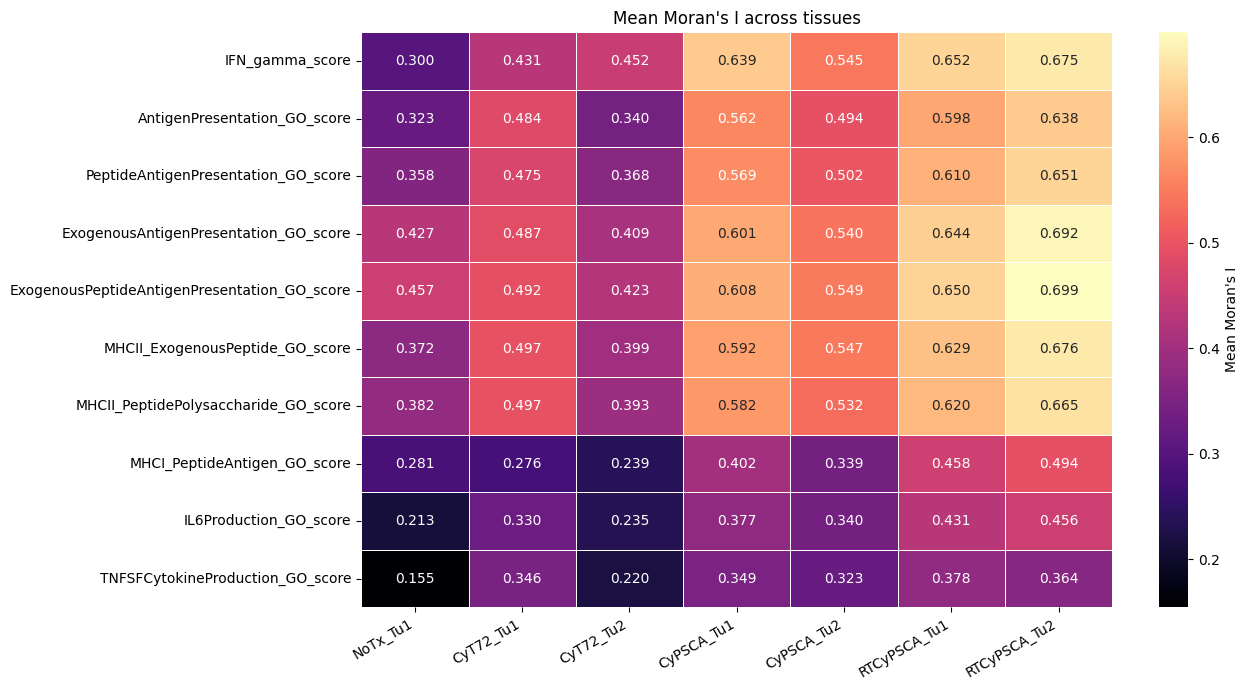

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_moransI_standalone/moranI_mean_heatmap_NoTx_Tu1_CyT72_Tu1_CyT72_Tu2_CyPSCA_Tu1_CyPSCA_Tu2_RTCyPSCA_Tu1_RTCyPSCA_Tu2.png


In [26]:
heatmap_treatments = analysis_treatments
heatmap_score_cols = score_cols

heatmap_df = (
    moran_df.loc[
        moran_df["treatment"].isin(heatmap_treatments)
        & moran_df["score_col"].isin(heatmap_score_cols)
    ]
    .groupby(["score_col", "treatment"], observed=True)["I"]
    .mean()
    .unstack("treatment")
    .reindex(index=heatmap_score_cols, columns=heatmap_treatments)
)

display(heatmap_df)

fig, ax = plt.subplots(
    figsize=(1.6 * len(heatmap_treatments) + 2, 0.55 * len(heatmap_score_cols) + 1.5)
)
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="magma",
    cbar_kws={"label": "Mean Moran's I"},
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("Mean Moran's I across tissues")
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

treatments_tag = "_".join(heatmap_treatments)
outfile = outdir / f"moranI_mean_heatmap_{treatments_tag}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {outfile}")


# Per-cell-type box plot of mean pathway score

For the selected pathway, computes mean score per (tissue, cell type), then plots a box+strip with `x = treatment`, `y = mean_score`, `hue = cell_type`. Each dot = one tissue. Edit `boxplot_cell_types` to pick which cell types to show, and `boxplot_score_col` / `boxplot_treatments` for the rest.

In [12]:
print("Available c2l_permissive cell types:")
print(sorted(adata.obs["c2l_permissive"].astype(str).unique().tolist()))
print("\nAvailable score columns:", score_cols)


Available c2l_permissive cell types:
['B', 'CD4_T', 'CD8_T', 'Cancer_cell', 'Classical_Mono', 'Endothelial', 'Erythrocyte', 'Fibroblast', 'Intermediate_Mac', 'M1_like_Mac', 'M2_like_Mac', 'N1_like_Neu', 'N2_like_Neu', 'NK', 'NKT', 'Nonclassical_Mono', 'Treg', 'Unknown', 'cDC', 'pDC']

Available score columns: ['IFN_gamma_score', 'AntigenPresentation_GO_score', 'PeptideAntigenPresentation_GO_score', 'ExogenousAntigenPresentation_GO_score', 'ExogenousPeptideAntigenPresentation_GO_score', 'MHCII_ExogenousPeptide_GO_score', 'MHCII_PeptidePolysaccharide_GO_score', 'MHCI_PeptideAntigen_GO_score', 'IL6Production_GO_score', 'TNFSFCytokineProduction_GO_score']


In [30]:
obs_sub

,sample,cell_id,region,TMA,mouse,tissue,condition,tumor_loc,replicate_num,c2l_argmax,...,IFN_gamma_score,AntigenPresentation_GO_score,PeptideAntigenPresentation_GO_score,ExogenousAntigenPresentation_GO_score,ExogenousPeptideAntigenPresentation_GO_score,MHCII_ExogenousPeptide_GO_score,MHCII_PeptidePolysaccharide_GO_score,MHCI_PeptideAntigen_GO_score,IL6Production_GO_score,TNFSFCytokineProduction_GO_score
F07839_1n2_OME_cellid_000000001-1,F07839_1n2_OME,F07839_1n2_OME_cellid_000000001-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,Classical_Mono,...,0.344240,0.261069,0.365885,0.673859,0.703418,0.697653,0.592007,0.324373,0.048042,0.078250
F07839_1n2_OME_cellid_000000022-1,F07839_1n2_OME,F07839_1n2_OME_cellid_000000022-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,Classical_Mono,...,0.193100,0.273475,0.304545,0.659074,0.753393,1.064896,0.884311,0.076230,0.141394,0.113098
F07839_1n2_OME_cellid_000000026-1,F07839_1n2_OME,F07839_1n2_OME_cellid_000000026-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,M1_like_Mac,...,0.343491,0.494271,0.713000,1.084021,1.245516,1.584257,1.458150,0.373342,0.185751,0.164998
F07839_1n2_OME_cellid_000000029-1,F07839_1n2_OME,F07839_1n2_OME_cellid_000000029-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,M1_like_Mac,...,0.191080,0.305774,0.517012,0.921967,1.056175,1.406427,1.213938,0.210324,0.205198,0.144219
F07839_1n2_OME_cellid_000000039-1,F07839_1n2_OME,F07839_1n2_OME_cellid_000000039-1,CyPSCA_1_1_cell_boundaries,F07839,CyPSCA_1_1,CyPSCA_1_1,CyPSCA,1,1,Classical_Mono,...,0.308591,0.123367,0.183554,0.382837,0.300886,0.616707,0.447772,0.003258,0.044142,0.054345
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
F08638_OME_cellid_000229143-1,F08638_OME,F08638_OME_cellid_000229143-1,RTCyPSCA_1_5_cell_boundaries,F08638,RTCyPSCA_1_2_2,RTCyPSCA_1_5,RTCyPSCA,1,5,Classical_Mono,...,0.439078,0.312824,0.304484,0.529646,0.523097,0.827537,0.709993,0.128550,0.192758,0.190759
F08638_OME_cellid_000229189-1,F08638_OME,F08638_OME_cellid_000229189-1,RTCyPSCA_1_5_cell_boundaries,F08638,RTCyPSCA_1_2_2,RTCyPSCA_1_5,RTCyPSCA,1,5,Classical_Mono,...,0.439279,0.282946,0.373113,0.549102,0.547241,0.496495,0.389415,0.274182,0.267925,0.241904
F08638_OME_cellid_000229364-1,F08638_OME,F08638_OME_cellid_000229364-1,RTCyPSCA_1_5_cell_boundaries,F08638,RTCyPSCA_1_2_2,RTCyPSCA_1_5,RTCyPSCA,1,5,Classical_Mono,...,0.448300,0.154823,0.080544,0.252657,0.204854,0.044197,0.076371,0.054722,0.044328,0.111256
F08638_OME_cellid_000229383-1,F08638_OME,F08638_OME_cellid_000229383-1,RTCyPSCA_1_5_cell_boundaries,F08638,RTCyPSCA_1_2_2,RTCyPSCA_1_5,RTCyPSCA,1,5,Classical_Mono,...,0.425588,0.306647,0.352089,0.514666,0.532657,0.643929,0.661756,0.189050,0.126069,0.211530


,tissue,treatment,c2l_permissive,mean_score
46,NoTx_1_1,NoTx_Tu1,Classical_Mono,0.216137
54,NoTx_1_4,NoTx_Tu1,Classical_Mono,0.115158
47,NoTx_1_1,NoTx_Tu1,M1_like_Mac,0.263257
48,NoTx_1_1,NoTx_Tu1,M2_like_Mac,0.238405
50,NoTx_1_2,NoTx_Tu1,M2_like_Mac,0.123551
...,...,...,...,...
78,RTCyPSCA_2_4,RTCyPSCA_Tu2,M1_like_Mac,0.509160
75,RTCyPSCA_2_3,RTCyPSCA_Tu2,M2_like_Mac,0.242323
79,RTCyPSCA_2_4,RTCyPSCA_Tu2,M2_like_Mac,0.377091
76,RTCyPSCA_2_3,RTCyPSCA_Tu2,cDC,0.145729


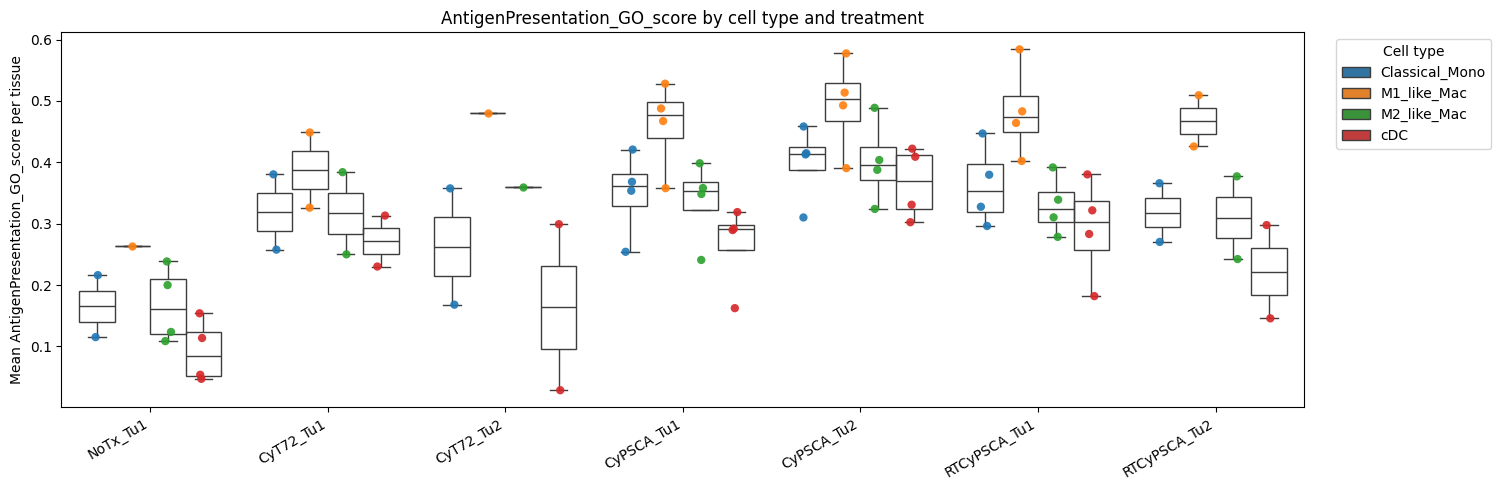

Saved: /coh_labs/yunroseli/Jona/CAR-T/results/pathway_moransI_standalone/boxplot_AntigenPresentation_GO_score_Classical_Mono_M1_like_Mac_M2_like_Mac_cDC_NoTx_Tu1_CyT72_Tu1_CyT72_Tu2_CyPSCA_Tu1_CyPSCA_Tu2_RTCyPSCA_Tu1_RTCyPSCA_Tu2.png


In [33]:
boxplot_score_col   = "AntigenPresentation_GO_score"
boxplot_treatments  = analysis_treatments
boxplot_cell_types  = ["Classical_Mono", "M1_like_Mac", "M2_like_Mac", "cDC"]

obs_sub = adata.obs.loc[
    adata.obs["treatment"].isin(boxplot_treatments)
    & adata.obs["c2l_permissive"].astype(str).isin(boxplot_cell_types)
].copy()

per_tissue = (
    obs_sub
    .groupby(["tissue", "treatment", "c2l_permissive"], observed=True)[boxplot_score_col]
    .mean()
    .reset_index()
    .rename(columns={boxplot_score_col: "mean_score"})
)

per_tissue["treatment"] = pd.Categorical(per_tissue["treatment"], categories=boxplot_treatments, ordered=True)
per_tissue["c2l_permissive"] = pd.Categorical(per_tissue["c2l_permissive"], categories=boxplot_cell_types, ordered=True)
per_tissue = per_tissue.sort_values(["treatment", "c2l_permissive"])

display(per_tissue)

fig, ax = plt.subplots(figsize=(1.8 * len(boxplot_treatments) + 2.5, 5))

sns.boxplot(
    data=per_tissue,
    x="treatment",
    y="mean_score",
    hue="c2l_permissive",
    order=boxplot_treatments,
    hue_order=boxplot_cell_types,
    showfliers=False,
    boxprops={"facecolor": "none"},
    whiskerprops={"linewidth": 1},
    ax=ax,
)
sns.stripplot(
    data=per_tissue,
    x="treatment",
    y="mean_score",
    hue="c2l_permissive",
    order=boxplot_treatments,
    hue_order=boxplot_cell_types,
    dodge=True,
    size=6,
    alpha=0.9,
    ax=ax,
)

# Deduplicate legend (boxplot + stripplot each add entries).
handles, labels = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    seen.setdefault(l, h)
ax.legend(seen.values(), seen.keys(), title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left")

ax.set_xlabel("")
ax.set_ylabel(f"Mean {boxplot_score_col} per tissue")
ax.set_title(f"{boxplot_score_col} by cell type and treatment")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

cells_tag = "_".join(boxplot_cell_types)
treatments_tag = "_".join(boxplot_treatments)
outfile = outdir / f"boxplot_{boxplot_score_col}_{cells_tag}_{treatments_tag}.png"
plt.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {outfile}")


In [ ]:
# ============================================================
# --- Inputs ---
# ============================================================
tissue_name   = "RTCyPSCA_2_3"

pathway_1     = "IFN_gamma_score"   # required — red channel (or solo colormap)
pathway_2     = "Glycolysis_score"  # optional — green channel  (None to disable)
top_quantile  = 0.25                # show top X% of pathway_1 cells (ignored in cell type mode)

cell_type_col = None                # e.g. "c2l_winner" — overrides all pathway coloring

he_alpha = 0.6
shrink   = 1
# ============================================================

image_key    = f"{tissue_name}_hires_tissue_image"
boundary_key = f"{tissue_name}_cell_boundaries"

image  = sdata.images[image_key].values
shapes = sdata.shapes[boundary_key].copy()

shapes["geometry"] = shapes["geometry"].convex_hull.buffer(-shrink)
scale, tx, ty = get_tissue_transform(sdata, tissue_name)
shapes["geometry"] = shapes["geometry"].apply(
    lambda geom: shapely_scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
)

mask  = adata.obs["tissue"] == tissue_name
a_sub = adata[mask]

# Join only columns that actually exist in obs
join_cols = [
    c for c in [pathway_1, pathway_2, cell_type_col]
    if c is not None and c in a_sub.obs.columns
]
shapes = shapes.join(a_sub.obs[join_cols], how="left")

# --- Filter / subset ---
if cell_type_col is not None:
    shapes_top = shapes.dropna(subset=[cell_type_col]).copy()
    print(f"Cell type mode: {len(shapes_top)}/{len(shapes)} cells")
else:
    threshold  = shapes[pathway_1].quantile(1 - top_quantile)
    shapes_top = shapes[shapes[pathway_1] >= threshold].copy()
    print(f"Showing {len(shapes_top)}/{len(shapes)} cells "
          f"(top {top_quantile*100:.0f}% of {pathway_1}, threshold={threshold:.3f})")

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 10))
img_rgb = np.transpose(image, (1, 2, 0))
h, w    = img_rgb.shape[:2]
ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper", alpha=he_alpha)

if cell_type_col is not None:
    # --- Cell type mode: categorical colors ---
    from matplotlib.patches import Patch
    cell_types   = shapes_top[cell_type_col].astype(str)
    unique_types = sorted(cell_types.unique())
    palette      = plt.cm.get_cmap("tab20", len(unique_types))
    color_map    = {ct: palette(i) for i, ct in enumerate(unique_types)}
    colors       = [color_map[ct] for ct in cell_types]

    shapes_top.plot(ax=ax, color=colors, edgecolor="black", linewidth=0.3, alpha=0.85)
    handles = [Patch(facecolor=color_map[ct], label=ct) for ct in unique_types]
    ax.legend(handles=handles, loc="upper right", fontsize=7,
              title=cell_type_col, title_fontsize=8, framealpha=0.8)
    title_str = f"{tissue_name} — {cell_type_col}"

elif pathway_2 is not None and pathway_2 in shapes_top.columns:
    # --- Two-pathway RGB blend: P1 → red, P2 → green, both → yellow ---
    p1 = shapes_top[pathway_1].rank(pct=True).fillna(0).values
    p2 = shapes_top[pathway_2].rank(pct=True).fillna(0).values
    colors = [(r, g, 0.0, 0.85) for r, g in zip(p1, p2)]

    shapes_top.plot(ax=ax, color=colors, edgecolor="none", linewidth=0)

    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color=(1, 0, 0),    label=f"{pathway_1} only"),
        Patch(color=(0, 0.8, 0),  label=f"{pathway_2} only"),
        Patch(color=(1, 0.85, 0), label="Both high"),
    ], loc="upper right", framealpha=0.8)
    title_str = f"{tissue_name} — {pathway_1} (red)  ✕  {pathway_2} (green)"

else:
    # --- Single pathway: magma colormap ---
    shapes_top.plot(
        column=pathway_1, cmap="magma", ax=ax,
        alpha=0.85, edgecolor="black", linewidth=0.3,
        legend=True, legend_kwds={"label": pathway_1, "shrink": 0.5},
    )
    title_str = f"{tissue_name} — {pathway_1} (top {top_quantile*100:.0f}%)"

ax.set_title(title_str, fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()
